# EDA 
I will address the following questions::
1. What is the population distribution?
2. Which variables are correlated with `default`?
3. Is the `target` variable imbalanced?
4. Which features are useful for `scoring`?
5. What are the main data quality issues?

### Dataset overview

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df= pd.read_csv('../data/raw/bank.csv', sep= ';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


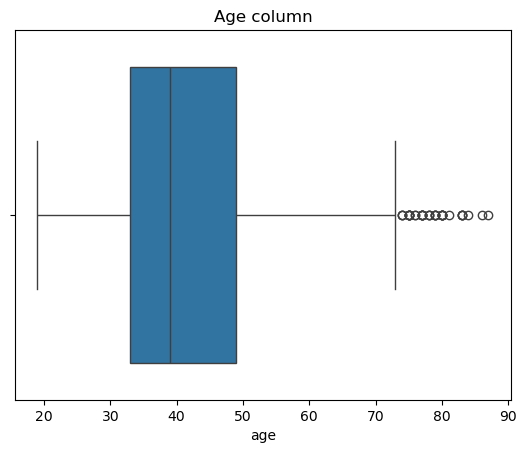

In [4]:
# I'm going to check the "age" column
ax1= sns.boxplot(x=df['age'])
ax1.set_title("Age column")
plt.show()

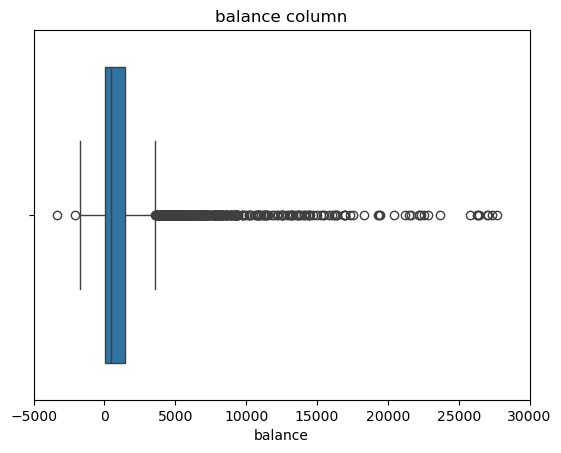

In [5]:
# I'm going to check the "balance" columns
fig, ax= plt.subplots()
sns.boxplot(x= df['balance'], ax= ax)
ax.set_title('balance column')

# Zoom in
ax.set_xlim(-5000, 30000)
plt.show()

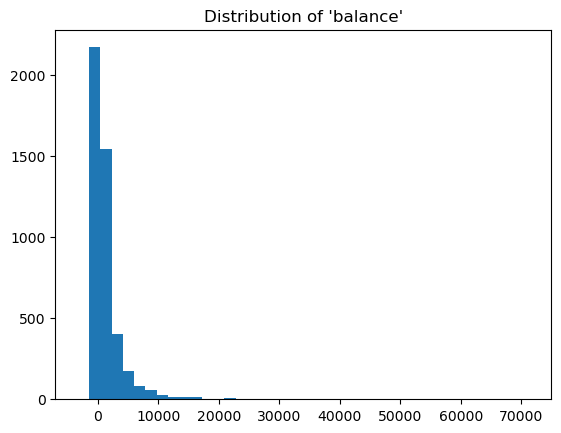

In [6]:
# Distribution of balance
plt.hist(df['balance'], bins= 40)
plt.title("Distribution of 'balance'")
plt.show()

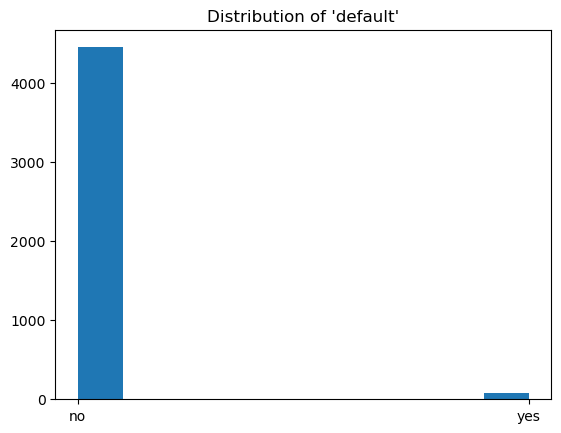

default
no     4445
yes      76
Name: count, dtype: int64


In [7]:
# Distribution of "default"
plt.hist(df['default'])
plt.title("Distribution of 'default'")
plt.show()
print(df['default'].value_counts())

In [8]:
classes= df['default'].value_counts(normalize= True) * 100
for name_class, percentage in classes.items():
    print(f"Class {name_class}: {percentage:.2f}")

Class no: 98.32
Class yes: 1.68


In [9]:
# I will check the categorical variables
# unique values
df['job'].unique()

array(['unemployed', 'services', 'management', 'blue-collar',
       'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
       'housemaid', 'retired', 'unknown'], dtype=object)

In [10]:
df['education'].unique()

array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object)

- Every row has the correct data type.
- The DF does not contain null values.
- `age` is clean and does not require outlier treatment; It will be bucketized later.
- `balance` is strongly left-skewed and contains extreme outliers.
- There is a clear class imbalance in the `default` target variable.
- `job` and `education` do not contain unusual or inconsistent categories.
- The variable `y` represents marketing campaign success and is not related to credit risk. Therefore, it is excluded from the scoring model.
- The dataset is highly imbalanced, with approximately 98.31% non-default and 1.68% default cases. This imbalance will require special handling during model training (class weights, resampling, or threshold tuning).

| Column   | Type        | Domain           | Use          |
| -------- | ----------- | ---------------- | ------------ |
| age      | numeric     | demographic      | yes          |
| job      | categorical | demographic      | yes          |
| marital  | categorical | demographic      | yes          |
| education| categorical | demographic      | yes          |
| default  | numeric     | financial        | yes          |
| balance  | numeric     | financial        | yes          |
| housing  | binary      | financial        | yes          |
| loan     | binary      | financial        | yes          |
| contact  | categorical | marketing        | no           |
| day      | categorical | marketing        | no           |
| month    | categorical | marketing        | no           |
| duration | numeric     | marketing        | no(data leakage)|
| campaign | numeric     | marketing        | no           |
| pdays    | numeric     | marketing        | no           |
| previous | numeric     | marketing        | no           |
| poutcome | categorical | marketing        | no           |
| y        | binary      | categorical      | no           |

### Bivariate Analysis

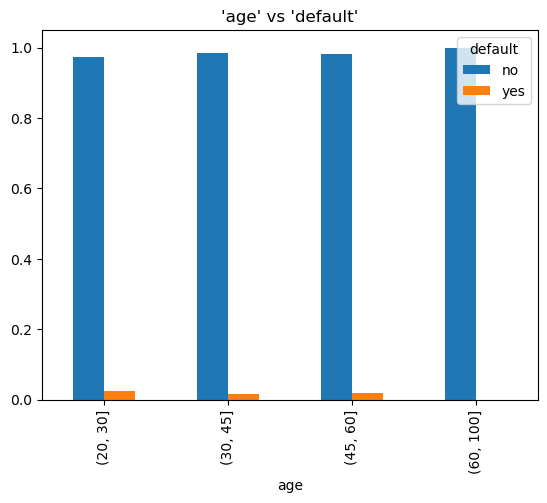

In [11]:
# I will check the variables are correlated with "default"
bins= [20, 30, 45, 60, 100]
age_grouped= pd.cut(df['age'], bins= bins)
pd.crosstab(age_grouped, df['default'], normalize= 'index').plot(kind= 'bar')
plt.title("'age' vs 'default'")
plt.show()


- Younger clients show higher default rates.
- Middle-aged clients (30-45) presents lowest risk.
- `age` will be included as a bucketized feature for scoring.

In [12]:
# Quartiles of "balance"
df['balance'].describe()

count     4521.000000
mean      1422.657819
std       3009.638142
min      -3313.000000
25%         69.000000
50%        444.000000
75%       1480.000000
max      71188.000000
Name: balance, dtype: float64

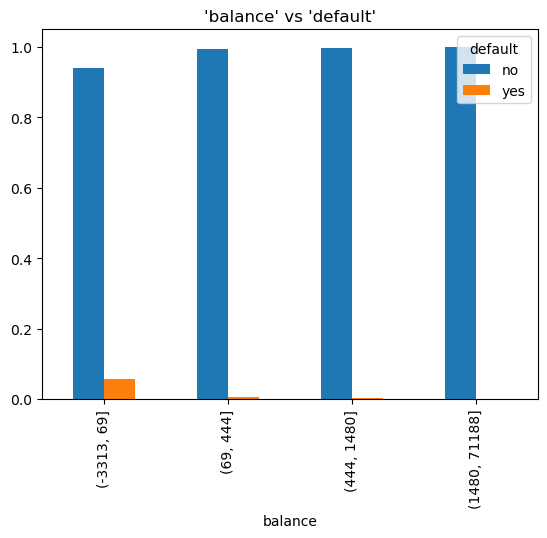

In [13]:
bins_balance= [-3313, 69, 444, 1480, 71188]
balance_grouped= pd.cut(df['balance'], bins= bins_balance)
pd.crosstab(balance_grouped, df['default'], normalize= 'index').plot(kind= 'bar')
plt.title("'balance' vs 'default'")
plt.show()

- Balance is the strongest predictor observed so far
- Customers with low or negative balances concentrate most defaults
- The variable will be discretized and heavily weighted in the scoring model

In [14]:
# The target to binary
df['default_binary']= df['default'].map({'yes': 1, 'no': 0})

In [15]:
# "job" column
df['job'].value_counts()

job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64

In [16]:
# Calculating risk rate
job_group= df.groupby('job')['default_binary'].mean().sort_values(ascending= False) * 100
job_group

job
entrepreneur     4.166667
unemployed       2.343750
self-employed    2.185792
technician       1.953125
housemaid        1.785714
services         1.678657
blue-collar      1.479915
management       1.444788
retired          1.304348
admin.           1.255230
student          1.190476
unknown          0.000000
Name: default_binary, dtype: float64

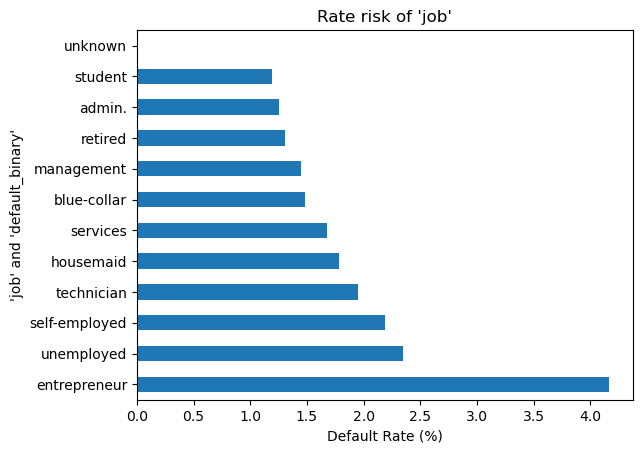

In [17]:
job_group.plot(kind= 'barh')
plt.title("Rate risk of 'job'")
plt.xlabel("Default Rate (%)")
plt.ylabel("'job' and 'default_binary'")
plt.show()

- `job` type shows moderate predictive power. "entrepreneurs" and "unemployed" customers present default rates significantly above the dataset average, while students and management positions show lower risk. This feature will be included in the scoring model with moderate weight.

In [18]:
# "housing" vs "default"
housing_group= df.groupby('housing')['default_binary'].mean().sort_values() * 100
housing_group

housing
no     1.580020
yes    1.758499
Name: default_binary, dtype: float64

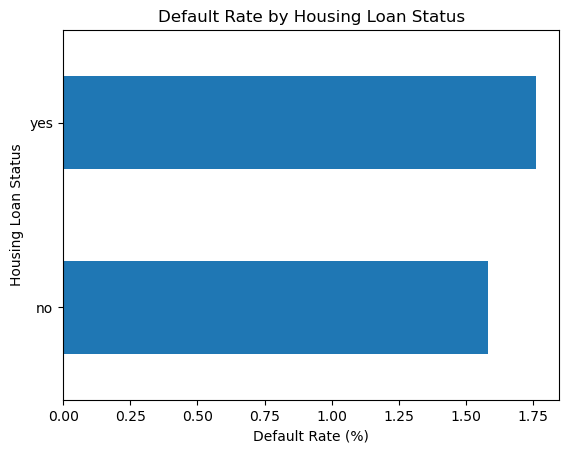

In [19]:
housing_group.plot(kind= 'barh')
plt.title("Default Rate by Housing Loan Status")
plt.xlabel("Default Rate (%)")
plt.ylabel("Housing Loan Status")
plt.show()

- Customers with housing loans show a slightly higher default rate, but the difference is marginal.
- Housing loan status shows a weak relationship with default risk. Customers with existing housing loans present slightly higher default rates, but the difference is not substantial. This feature may be included in the model with low weight.

In [20]:
# I will check "loan" vs "default"
loan_grouped= df.groupby('loan')['default_binary'].mean() * 100
loan_grouped

loan
no     1.331593
yes    3.617945
Name: default_binary, dtype: float64

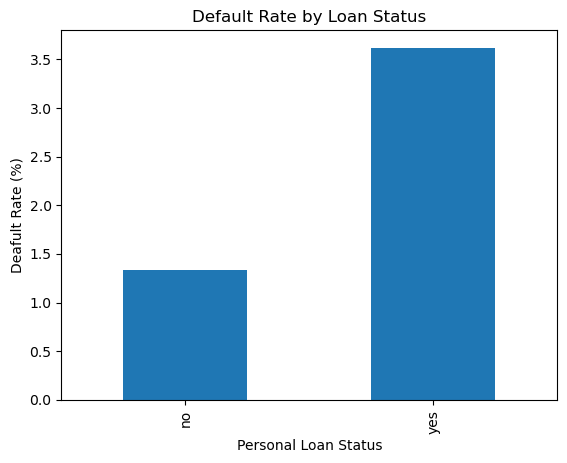

In [21]:
loan_grouped.plot(kind= 'bar')
plt.title('Default Rate by Loan Status')
plt.xlabel('Personal Loan Status')
plt.ylabel('Deafult Rate (%)')
plt.show()

- Personal loan status shows strong predictive power. Customers with an active loan present a default rate almost three times higher than customers without a one.
This variable will be included in the scoring model with a significant weight.

In [22]:
# I will check "education" vs "default"
education_grouped= df.groupby('education')['default_binary'].mean() * 100
education_grouped

education
primary      1.474926
secondary    1.994796
tertiary     1.259259
unknown      1.604278
Name: default_binary, dtype: float64

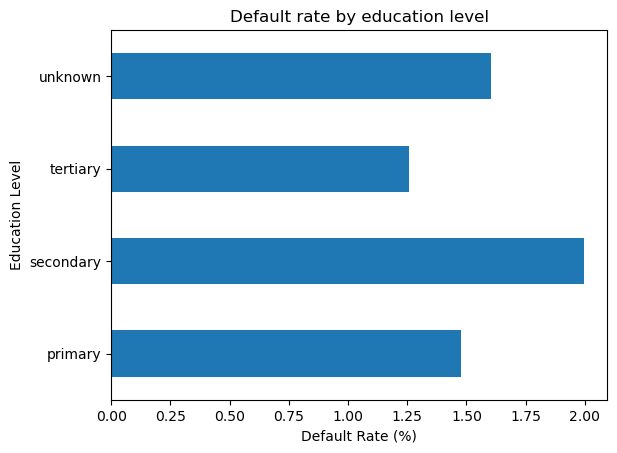

In [23]:
education_grouped.plot(kind="barh")
plt.title("Default rate by education level")
plt.xlabel("Default Rate (%)")
plt.ylabel("Education Level")
plt.show()

- Education level shows moderate predictive power. Lower education levels are associated with higher default rates, but the separation is weaker than financial variables such as `balance` or `loan` status.

In [24]:
# I will check "marital" vs "default"
marital_grouped= df.groupby("marital")['default_binary'].mean() * 100
marital_grouped


marital
divorced    3.409091
married     1.287093
single      1.839465
Name: default_binary, dtype: float64

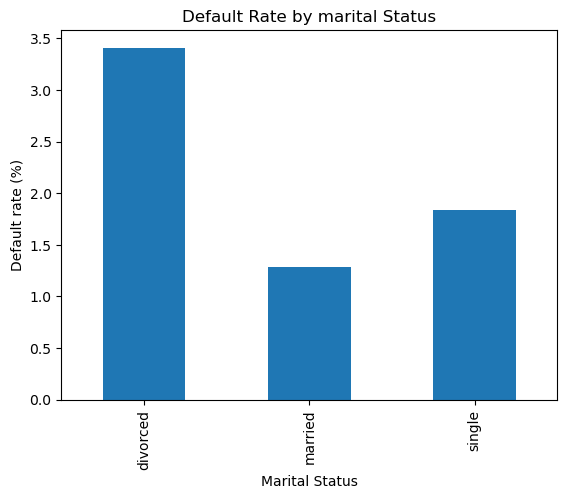

In [25]:
marital_grouped.plot(kind='bar')
plt.title("Default Rate by marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default rate (%)")
plt.show()

- Divorced customers presents the highest default risk, almost 2.6x higher than married customers.

### Key EDA Findings (Summary)
- The dataset represents a typical retail banking population, dominated by middle-aged customers, stable employment, and secondary/tertiary education levels.
- The target variable `default` is severely imbalanced:
    - 98.32% non-default
    - 1.68% default
- Features most correlated with `default`:
    - High `balance`, `loan`
    - Medium `age`, `job`, `education`, `marital`
    - Low `housing`
- Customers with:
    - low account balances,
    - active personale loans,
    - younger age,
    - and occupations such as entrepreneur or unemployed show higher default risk
- Data quality is strong
- Selected features for scoring model:
    - `balance`
    - `loan`
    - `age`
    - `job`
    - `education`
    - `marital`
    - `housing`


### Feature overview

| Feature  | Predictive Power | Recomendation    | 
| -------- | ---------------- | ---------------- |
| balance  | high             | include          | 
| loan     | high             | include          |
| age      | medium           | include          |
| job      | medium           | include          |
| education| medium           | include          |
| marital  | medium-low       | include          |
| housing  | low              | optional         |
